In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

# ---------------------------
# Load Cleveland Dataset
# ---------------------------
df = pd.read_csv("cleveland_heart_disease.csv")

# Convert target: >0 → 1 (disease), 0 → 0 (no disease)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# ---------------------------
# Feature Selection (ORDER LOCKED)
# ---------------------------
FEATURES = [
    'age',      # 0
    'sex',      # 1
    'cp',       # 2
    'trestbps', # 3
    'chol',     # 4
    'fbs',      # 5
    'restecg',  # 6
    'thalach',  # 7
    'exang',    # 8
    'oldpeak',  # 9
    'slope',    # 10
    'ca',       # 11
    'thal'      # 12
]

X = df[FEATURES]
y = df['target']

# ---------------------------
# Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------
# Train Model (NO SCALING)
# ---------------------------
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# ---------------------------
# Evaluation
# ---------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ---------------------------
# Save Model for Streamlit
# ---------------------------
joblib.dump(
    {
        "model": model,
        "features": FEATURES
    },
    "heart_attack.pkl"
)

print("\n✅ Model trained and saved as heart_attack.pkl")

# ---------------------------
# Sanity Check (VERY IMPORTANT)
# ---------------------------
sample = X_test.iloc[[0]]
print("\nSample Prediction:", model.predict(sample))
print("Sample Probability:", model.predict_proba(sample))


Accuracy: 0.9016393442622951

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61


Confusion Matrix:
 [[28  5]
 [ 1 27]]

✅ Model trained and saved as heart_attack.pkl

Sample Prediction: [0]
Sample Probability: [[0.69957694 0.30042306]]


Dataset Head:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset Description:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198 

C:\Users\M\AppData\Local\Temp\ipykernel_12956\2463162024.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


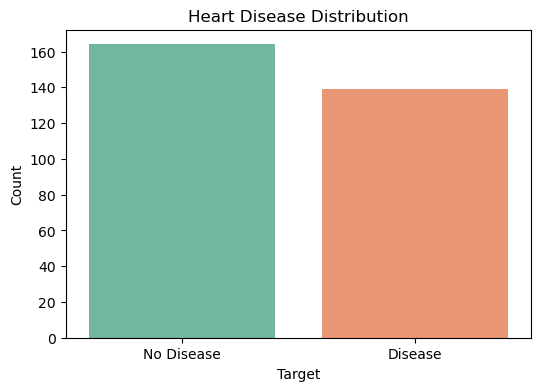

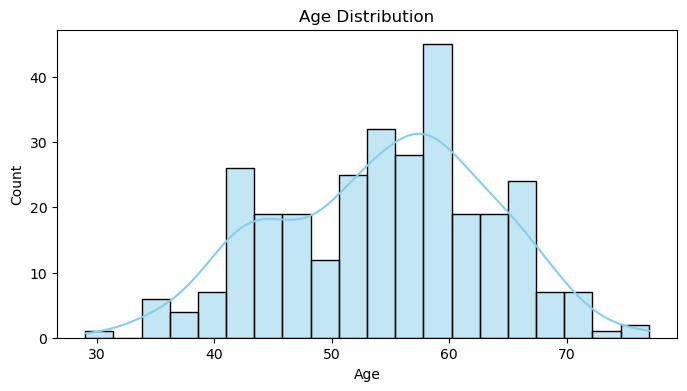

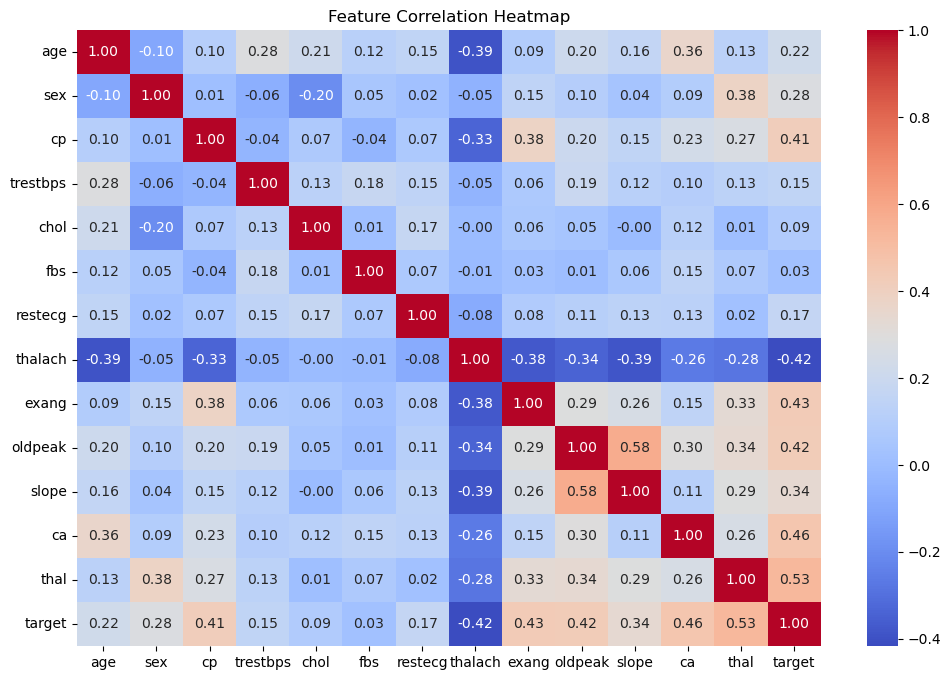

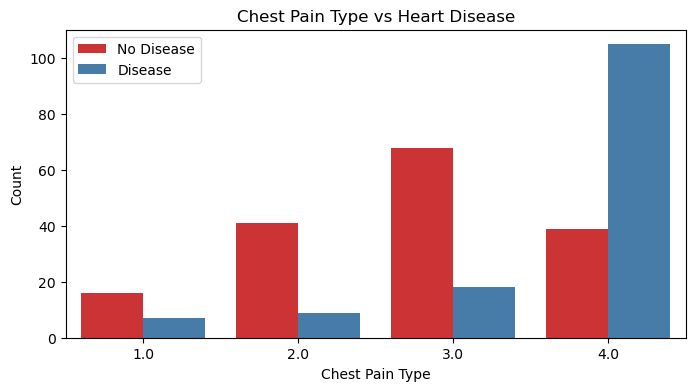

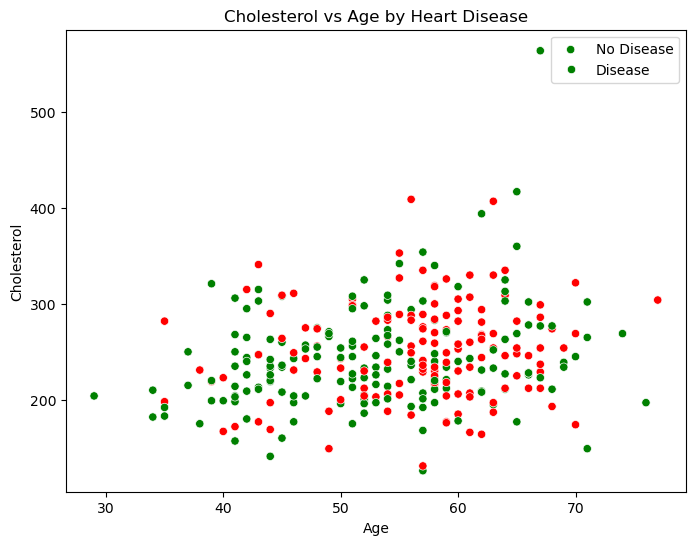

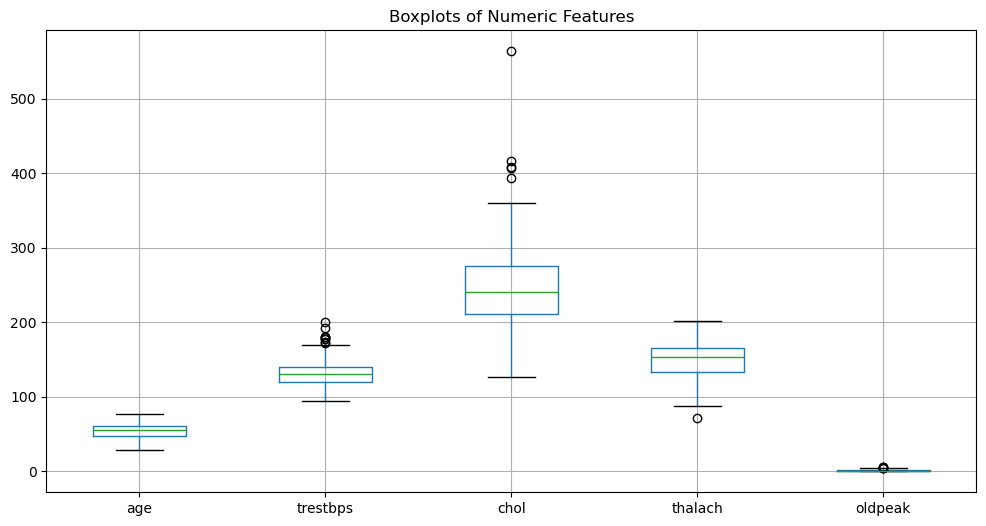

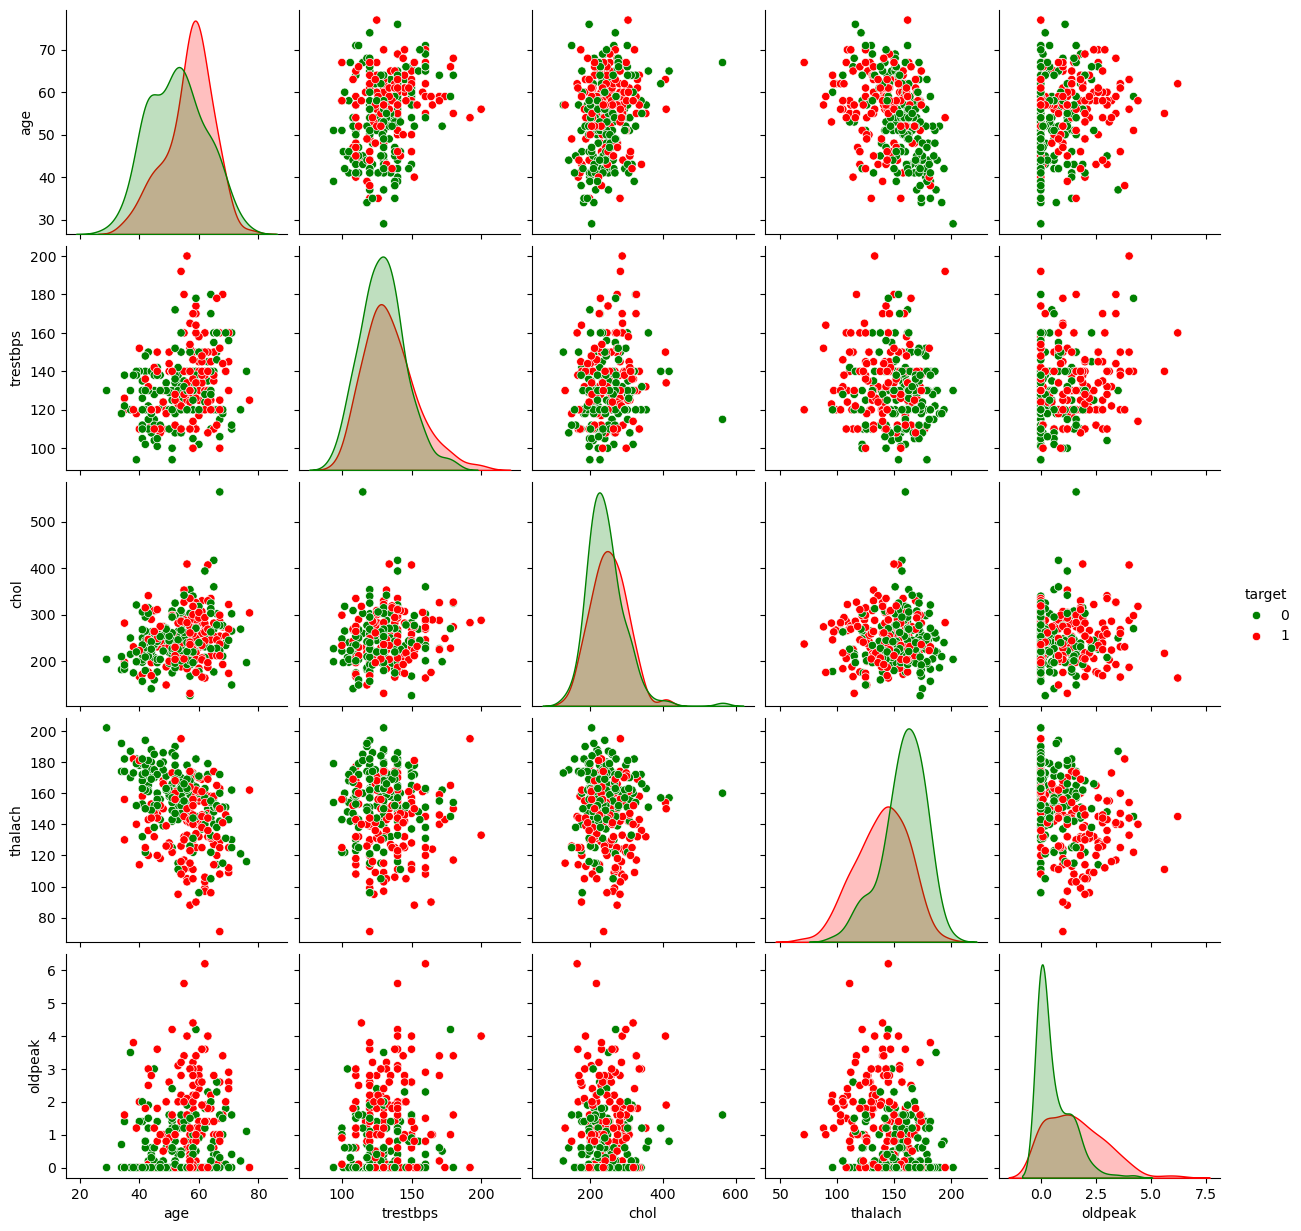

All plots generated and saved as PNG files.


In [10]:
# visualize_heart_data.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Load Dataset
# ---------------------------
# Replace with your CSV dataset file
df = pd.read_csv("cleveland_heart_disease.csv")

# ---------------------------
# Basic Info
# ---------------------------
print("Dataset Head:")
print(df.head())
print("\nDataset Description:")
print(df.describe())

# ---------------------------
# Visualization 1: Target Distribution
# ---------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df, palette="Set2")
plt.xticks([0,1], ["No Disease", "Disease"])
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.savefig("target_distribution.png", dpi=300)
plt.show()

# ---------------------------
# Visualization 2: Age Distribution
# ---------------------------
plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("age_distribution.png", dpi=300)
plt.show()

# ---------------------------
# Visualization 3: Correlation Heatmap
# ---------------------------
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

# ---------------------------
# Visualization 4: Chest Pain Type vs Target
# ---------------------------
plt.figure(figsize=(8,4))
sns.countplot(x="cp", hue="target", data=df, palette="Set1")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.title("Chest Pain Type vs Heart Disease")
plt.legend(["No Disease", "Disease"])
plt.savefig("cp_vs_target.png", dpi=300)
plt.show()

# ---------------------------
# Visualization 5: Cholesterol vs Age Scatter
# ---------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x="age", y="chol", hue="target", data=df, palette=["green", "red"])
plt.title("Cholesterol vs Age by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.legend(["No Disease", "Disease"])
plt.savefig("chol_vs_age.png", dpi=300)
plt.show()

# ---------------------------
# Visualization 6: Boxplots of Numeric Features
# ---------------------------
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
plt.figure(figsize=(12,6))
df[numeric_features].boxplot()
plt.title("Boxplots of Numeric Features")
plt.savefig("numeric_boxplots.png", dpi=300)
plt.show()

# ---------------------------
# Optional: Pairplot
# ---------------------------
sns.pairplot(df, hue="target", palette=["green", "red"], vars=numeric_features)
plt.savefig("pairplot_features.png", dpi=300)
plt.show()

print("All plots generated and saved as PNG files.")